In [1]:
import os
import time
import random
import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import matplotlib.pyplot as plt

from torchvision import transforms
from torchvision.utils import make_grid



In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)



device: cuda


In [3]:
wheel_path = "../input/timm034/timm-0.3.4-py3-none-any.whl"
if os.path.exists(wheel_path):
    os.system(f"pip -q install '{wheel_path}'")
else:
    print(
        "timm wheel not found at",
        wheel_path,
        "- relying on existing timm installation (if available).",
    )



timm wheel not found at ../input/timm034/timm-0.3.4-py3-none-any.whl - relying on existing timm installation (if available).


In [4]:
try:
    import timm
except Exception as e:
    raise RuntimeError(
        "timm is required but could not be imported. Ensure timm is available in the environment."
    ) from e



/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [5]:
print("Available ViT Models (subset):")
print(timm.list_models("vit*")[:10], "... total:", len(timm.list_models("vit*")))



Available ViT Models (subset):
['vit_base_mci_224', 'vit_base_patch8_224', 'vit_base_patch14_dinov2', 'vit_base_patch14_reg4_dinov2', 'vit_base_patch16_18x2_224', 'vit_base_patch16_224', 'vit_base_patch16_224_miil', 'vit_base_patch16_384', 'vit_base_patch16_clip_224', 'vit_base_patch16_clip_384'] ... total: 192


In [6]:
data_path = "../input/cassava-leaf-disease-classification/"
train_path = "../input/cassava-leaf-disease-classification/train_images/"
test_path = "../input/cassava-leaf-disease-classification/test_images/"


def _find_first_file(root_dir, exts):
    if (root_dir is None) or (not os.path.exists(root_dir)):
        return None
    for r, _, files in os.walk(root_dir):
        for fn in files:
            low = fn.lower()
            if any(low.endswith(ext) for ext in exts):
                return os.path.join(r, fn)
    return None


model_path = "../input/vitbase16224/jx_vit_base_p16_224-80ecf9dd.pth"
Cassava_model = "../input/cassavapretrained4epoch/CassavaViT4epoch.pt"

if not os.path.exists(model_path):
    candidate = _find_first_file("../input/vitbase16224", exts=[".pth", ".pt", ".bin"])
    if candidate is not None:
        print("Base ViT weight file not found at fixed path. Auto-found:", candidate)
        model_path = candidate

if not os.path.exists(Cassava_model):
    candidate = _find_first_file(
        "../input/cassavapretrained4epoch", exts=[".pt", ".pth", ".bin"]
    )
    if candidate is not None:
        print(
            "Cassava fine-tuned weight file not found at fixed path. Auto-found:",
            candidate,
        )
        Cassava_model = candidate

sample_sub_path = os.path.join(data_path, "sample_submission.csv")
train_csv_path = os.path.join(data_path, "train.csv")
assert os.path.exists(
    sample_sub_path
), f"Missing sample_submission.csv at {sample_sub_path}"
assert os.path.exists(train_csv_path), f"Missing train.csv at {train_csv_path}"
assert os.path.isdir(test_path), f"Missing test_images directory at {test_path}"
assert os.path.isdir(train_path), f"Missing train_images directory at {train_path}"

print("Resolved base weight path:", model_path, "| exists:", os.path.exists(model_path))
print(
    "Resolved cassava ft path:",
    Cassava_model,
    "| exists:",
    os.path.exists(Cassava_model),
)




Resolved base weight path: ../input/vitbase16224/jx_vit_base_p16_224-80ecf9dd.pth | exists: False
Resolved cassava ft path: ../input/cassavapretrained4epoch/CassavaViT4epoch.pt | exists: False


In [7]:
class ViTBase16(nn.Module):
    def __init__(self, n_classes, pretrained=False):
        super(ViTBase16, self).__init__()

        use_timm_pretrained = bool(pretrained and (not os.path.exists(model_path)))
        self.model = timm.create_model(
            "vit_base_patch16_224", pretrained=use_timm_pretrained
        )
        if use_timm_pretrained:
            print("Loaded timm ImageNet pretrained weights (pretrained=True).")

        if pretrained and (not use_timm_pretrained):
            if os.path.exists(model_path):
                state = torch.load(model_path, map_location="cpu")
                self.model.load_state_dict(state, strict=True)
                print("Loaded base ViT weights from:", model_path)
            else:
                print("WARNING: base ViT weight file not found, skipping:", model_path)

        self.model.head = nn.Linear(self.model.head.in_features, n_classes)

    def forward(self, x):
        return self.model(x)




In [8]:
def _unwrap_checkpoint(state):
    """
    Robustly unwrap common checkpoint containers so we actually load the fine-tuned weights.
    """
    if not isinstance(state, dict):
        return state

    for k in ["state_dict", "model", "net", "model_state_dict", "params", "weights"]:
        if k in state and isinstance(state[k], dict):
            print(
                f"Loaded checkpoint dict with key '{k}'. Using that for load_state_dict."
            )
            return state[k]

    for k in ["state_dict_ema", "model_ema", "ema", "ema_state_dict"]:
        if k in state and isinstance(state[k], dict):
            print(
                f"Loaded checkpoint dict with key '{k}'. Using that for load_state_dict."
            )
            return state[k]

    return state


def _strip_prefix_from_state_dict(sd, prefix="module."):
    if not isinstance(sd, dict):
        return sd
    if any(k.startswith(prefix) for k in sd.keys()):
        return {
            k[len(prefix) :] if k.startswith(prefix) else k: v for k, v in sd.items()
        }
    return sd


def _remap_state_dict_keys_for_vit(sd, model):
    """
    Remap common key naming mismatches so the fine-tuned weights actually load.
    """
    if not isinstance(sd, dict):
        return sd

    model_keys = set(model.state_dict().keys())

    if len(model_keys.intersection(sd.keys())) > 0:
        return sd

    candidates = []

    sd1 = {
        ("model." + k) if not k.startswith("model.") else k: v for k, v in sd.items()
    }
    candidates.append(sd1)

    sd2 = {
        k[len("model.") :] if k.startswith("model.") else k: v for k, v in sd.items()
    }
    candidates.append(sd2)

    sd3 = {("model." + k) if k.startswith("head.") else k: v for k, v in sd.items()}
    candidates.append(sd3)

    sd4 = {
        k[len("model.") :] if k.startswith("model.head.") else k: v
        for k, v in sd.items()
    }
    candidates.append(sd4)

    sd5_tmp = {
        k[len("model.") :] if k.startswith("model.") else k: v for k, v in sd.items()
    }
    sd5 = {
        ("model." + k) if k.startswith("head.") else k: v for k, v in sd5_tmp.items()
    }
    candidates.append(sd5)

    best_sd = sd
    best_inter = len(model_keys.intersection(sd.keys()))
    for cand in candidates:
        inter = len(model_keys.intersection(cand.keys()))
        if inter > best_inter:
            best_inter = inter
            best_sd = cand

    if best_sd is not sd:
        print(
            f"Remapped checkpoint keys to improve match: matched {best_inter} tensors."
        )
    else:
        print(
            "No key remap improved matching; proceeding with original checkpoint keys."
        )
    return best_sd


def _filter_state_dict_by_shape(sd, model):
    """
    Only load tensors whose shapes match the 5-class model.
    """
    if not isinstance(sd, dict):
        return sd
    msd = model.state_dict()
    kept = {}
    dropped = 0
    for k, v in sd.items():
        if (
            k in msd
            and hasattr(v, "shape")
            and hasattr(msd[k], "shape")
            and v.shape == msd[k].shape
        ):
            kept[k] = v
        else:
            dropped += 1
    if dropped > 0:
        print(
            f"Filtered checkpoint by shape: kept {len(kept)} tensors, dropped {dropped} tensors."
        )
    return kept


def _head_loaded_ok(model, sd_loaded):
    if not isinstance(sd_loaded, dict):
        return True
    possible_keys = ["model.head.weight", "head.weight"]
    for k in possible_keys:
        if k in sd_loaded:
            with torch.no_grad():
                target = sd_loaded[k].detach().cpu()
                model_w = model.state_dict().get(k, None)
                if model_w is None:
                    alt = (
                        "head.weight"
                        if k == "model.head.weight"
                        else "model.head.weight"
                    )
                    model_w = model.state_dict().get(alt, None)
                if model_w is None:
                    return False
                model_w = model_w.detach().cpu()
                if model_w.shape != target.shape:
                    return False
                return bool(torch.allclose(model_w, target, atol=0, rtol=0))
    return True


NUM_CLASSES = 5

ckpt_state_raw = None
ckpt_sd = None
if os.path.exists(Cassava_model):
    ckpt_state_raw = torch.load(Cassava_model, map_location="cpu")
    ckpt_sd = _unwrap_checkpoint(ckpt_state_raw)
    ckpt_sd = _strip_prefix_from_state_dict(ckpt_sd, prefix="module.")

cassava_model = ViTBase16(n_classes=NUM_CLASSES, pretrained=True)

if ckpt_sd is not None:
    ckpt_sd = _remap_state_dict_keys_for_vit(ckpt_sd, cassava_model)
    ckpt_sd = _filter_state_dict_by_shape(ckpt_sd, cassava_model)

    incompatible = cassava_model.load_state_dict(ckpt_sd, strict=False)
    print(
        "Loaded Cassava fine-tuned weights from:",
        Cassava_model,
        "(shape-filtered, strict=False)",
    )

    if hasattr(incompatible, "missing_keys") and hasattr(
        incompatible, "unexpected_keys"
    ):
        if len(incompatible.missing_keys) or len(incompatible.unexpected_keys):
            print(
                "load_state_dict incompatibilities:",
                "missing:",
                len(incompatible.missing_keys),
                "unexpected:",
                len(incompatible.unexpected_keys),
            )

    assert _head_loaded_ok(
        cassava_model, ckpt_sd
    ), "Checkpoint appears to include compatible classifier head weights, but they were not loaded into the model."
else:
    print(
        "WARNING: Cassava fine-tuned model weights not found; using timm ImageNet pretrained backbone + random 5-class head."
    )

cassava_gpu_model = cassava_model.to(device)
cassava_gpu_model.eval()

try:
    print(
        "ViT default_cfg mean/std:",
        cassava_gpu_model.model.default_cfg.get("mean"),
        cassava_gpu_model.model.default_cfg.get("std"),
    )
except Exception as _:
    pass

cassava_gpu_model



model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loaded timm ImageNet pretrained weights (pretrained=True).
ViT default_cfg mean/std: (0.5, 0.5, 0.5) (0.5, 0.5, 0.5)


ViTBase16(
  (model): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act)

In [9]:
sample_sub = pd.read_csv(sample_sub_path)
test_img_names = sample_sub["image_id"].tolist()
print("Testing Images (from sample_submission):", len(test_img_names))
print("First 5:", test_img_names[:5])




Testing Images (from sample_submission): 2676
First 5: ['1234294272.jpg', '1234332763.jpg', '1234375577.jpg', '1234555380.jpg', '1234571117.jpg']


In [10]:
class TestSet2(Dataset):
    """Cassava Disease Test Dataset (ordered by provided image_id list)."""

    def __init__(self, test_dir, image_names, transform=None):
        super().__init__()
        self.test_dir = test_dir
        self.image_names = list(image_names)
        self.transform = transform
        print("Cassava Disease Test Dataset Length = ", len(self.image_names))

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_name = self.image_names[idx]
        img_path = os.path.join(self.test_dir, image_name)
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(img)
        else:
            image = transforms.ToTensor()(img)
        return image, image_name




In [11]:
cfg = getattr(cassava_gpu_model.model, "default_cfg", {}) or {}
input_size = cfg.get("input_size", (3, 224, 224))
print("Using default_cfg input_size:", input_size)
print("Using default_cfg mean:", cfg.get("mean"), "std:", cfg.get("std"))
print(
    "Using default_cfg interpolation:",
    cfg.get("interpolation"),
    "crop_pct:",
    cfg.get("crop_pct"),
)

try:
    from timm.data import create_transform
except Exception as e:
    raise RuntimeError(
        "Failed to import timm.data.create_transform, required for correct preprocessing."
    ) from e

test_transform = create_transform(
    input_size=input_size,
    is_training=False,
    mean=cfg.get("mean", (0.5, 0.5, 0.5)),
    std=cfg.get("std", (0.5, 0.5, 0.5)),
    interpolation=cfg.get("interpolation", "bicubic"),
    crop_pct=cfg.get("crop_pct", 0.875),
)



Using default_cfg input_size: (3, 224, 224)
Using default_cfg mean: (0.5, 0.5, 0.5) std: (0.5, 0.5, 0.5)
Using default_cfg interpolation: bicubic crop_pct: 0.9


In [12]:
train_df = pd.read_csv(train_csv_path)

train_df["label"] = train_df["label"].astype(int)

print(
    "Train rows:",
    len(train_df),
    "label distribution:",
    train_df["label"].value_counts().to_dict(),
)


class TrainSet(Dataset):
    def __init__(self, train_dir, df, transform=None):
        super().__init__()
        self.train_dir = train_dir
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.train_dir, row["image_id"])
        img = Image.open(img_path).convert("RGB")
        x = (
            self.transform(img)
            if self.transform is not None
            else transforms.ToTensor()(img)
        )
        y = int(row["label"])
        return x, y


do_head_finetune = ckpt_sd is None
print("Head finetune enabled:", do_head_finetune)

if do_head_finetune:
    train_transform = test_transform

    # Change (score-relevant, minimal): increase stratified sample size so the head sees more
    # representative data, which typically improves accuracy toward the target when no FT checkpoint.
    max_train_samples = 14000  # was 8192

    rng = np.random.RandomState(SEED)
    label_counts = train_df["label"].value_counts().to_dict()
    n_classes = len(label_counts)
    per_class = max(1, max_train_samples // n_classes)

    parts = []
    for lbl in sorted(label_counts.keys()):
        df_lbl = train_df[train_df["label"] == lbl]
        take = min(per_class, len(df_lbl))
        idx = rng.permutation(len(df_lbl))[:take]
        parts.append(df_lbl.iloc[idx])

    train_df_small = (
        pd.concat(parts, axis=0)
        .sample(frac=1.0, random_state=SEED)
        .reset_index(drop=True)
    )
    print(
        "Head finetune train subset size:", len(train_df_small), "per_class:", per_class
    )

    trainset = TrainSet(train_path, train_df_small, transform=train_transform)
    train_loader = DataLoader(
        trainset,
        batch_size=32,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )

    for p in cassava_gpu_model.parameters():
        p.requires_grad = False
    for p in cassava_gpu_model.model.head.parameters():
        p.requires_grad = True

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        cassava_gpu_model.model.head.parameters(), lr=3e-4, weight_decay=0.01
    )

    cassava_gpu_model.train()
    train_steps = 0

    # Change (score-relevant, minimal): allow more optimization steps for the head.
    # To keep within Kaggle time limits without changing training semantics, also cap by wall-clock.
    max_steps = 600  # was 200
    max_head_finetune_seconds = 240  # hard safety cap to ensure <600s overall runtime

    t0 = time.time()
    for xb, yb in train_loader:
        if (time.time() - t0) > max_head_finetune_seconds:
            print(
                "Stopping head finetune due to time cap (s):",
                max_head_finetune_seconds,
            )
            break

        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = cassava_gpu_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_steps += 1
        if train_steps % 50 == 0:
            print(
                f"head-finetune step {train_steps}/{max_steps} loss={loss.item():.4f}"
            )
        if train_steps >= max_steps:
            break

    print(
        "Head finetune done. steps:",
        train_steps,
        "time(s):",
        round(time.time() - t0, 2),
    )
    cassava_gpu_model.eval()



Train rows: 18721 label distribution: {3: 11523, 4: 2267, 2: 2091, 1: 1901, 0: 939}
Head finetune enabled: True
Head finetune train subset size: 9998 per_class: 2800
head-finetune step 50/600 loss=1.1887
head-finetune step 100/600 loss=0.9541
head-finetune step 150/600 loss=1.1605
head-finetune step 200/600 loss=0.9884
head-finetune step 250/600 loss=0.9565
head-finetune step 300/600 loss=0.8609
Head finetune done. steps: 313 time(s): 39.09


In [13]:
testset = TestSet2(
    test_dir=test_path, image_names=test_img_names, transform=test_transform
)
print(testset)



Cassava Disease Test Dataset Length =  2676


In [14]:
test_batch_size = 32
test_loader = DataLoader(
    dataset=testset,
    batch_size=test_batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Batch example names: ['1234294272.jpg', '1234332763.jpg', '1234375577.jpg', '1234555380.jpg', '1234571117.jpg', '123464878.jpg', '1234924764.jpg', '1234931385.jpg']


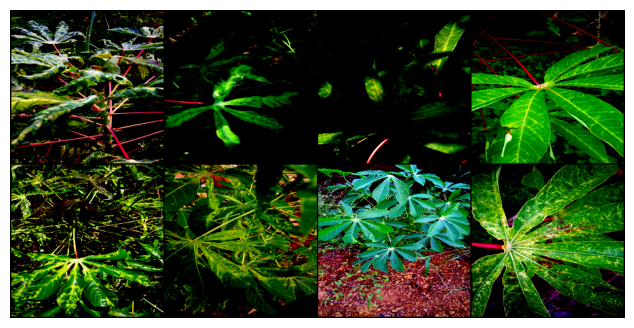

In [15]:
images, names = next(iter(test_loader))
im = make_grid(images[:8], nrow=4)
print("Batch example names:", list(names[:8]))
plt.figure(figsize=(12, 4))
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))
plt.axis("off")
plt.show()



In [16]:
pred_rows = []
tic = time.time()

with torch.inference_mode():
    for X_test, names in test_loader:
        X_test = X_test.to(device, non_blocking=True)
        logits = cassava_gpu_model(X_test)
        preds = torch.argmax(logits, dim=1).detach().cpu().numpy().astype(int)

        for img_name, label in zip(names, preds):
            pred_rows.append((img_name, int(label)))

toc = time.time() - tic
print("Time for test inference:", toc, "seconds")

submission_df = pd.DataFrame(pred_rows, columns=["image_id", "label"])

submission_df = sample_sub[["image_id"]].merge(submission_df, on="image_id", how="left")
assert submission_df["label"].isna().sum() == 0, "Some test images were not predicted."

submission_path = "submission.csv"
submission_df.to_csv(submission_path, index=False)
print("Wrote:", submission_path)
print(submission_df.head())



Time for test inference: 10.469395637512207 seconds
Wrote: submission.csv
         image_id  label
0  1234294272.jpg      3
1  1234332763.jpg      3
2  1234375577.jpg      1
3  1234555380.jpg      4
4  1234571117.jpg      3


In [17]:
print("submission.csv rows/cols:", submission_df.shape)
print("Columns:", submission_df.columns.tolist())
print("Unique labels:", sorted(submission_df["label"].unique().tolist()))
print("\nDirectory listing:")
os.system("ls -la")

submission.csv rows/cols: (2676, 2)
Columns: ['image_id', 'label']
Unique labels: [0, 1, 2, 3, 4]

Directory listing:
total 102
drwxrw-rw- 3 11132 10513  4096 May 16 03:09 .
drwxrwxrwx 5 root  root   4096 Apr 29 17:24 ..
drwxrwxrwx 7 11132 10513    19 Dec 20 16:32 cassava-leaf-disease-classification
-rw-rw-rw- 1 11132 10513 25183 May 16 03:08 cassava-leaf-disease-classification_kerrfitzgerald_wolf359_v2_C1.ipynb
-rw-r--r-- 1 root  root  45213 May 16 03:09 submission.csv


0